In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [optuna]


In [2]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [4]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (537, 8)
Test set shape: (231, 8)


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [7]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters


[I 2026-03-18 18:03:06,815] A new study created in memory with name: no-name-30542a7d-ba64-4bd5-a36b-79cfa661b56f
[I 2026-03-18 18:03:06,969] Trial 0 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 110, 'max_depth': 4}. Best is trial 0 with value: 0.7635009310986964.
[I 2026-03-18 18:03:07,051] Trial 1 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 72, 'max_depth': 17}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-03-18 18:03:07,127] Trial 2 finished with value: 0.7560521415270017 and parameters: {'n_estimators': 79, 'max_depth': 3}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-03-18 18:03:07,312] Trial 3 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 167, 'max_depth': 19}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-03-18 18:03:07,413] Trial 4 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 103, 'max_depth': 4}. Best is trial 1 with value: 0.774674115

In [8]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7783985102420857
Best hyperparameters: {'n_estimators': 126, 'max_depth': 7}


In [9]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set

y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.75


## Samplers in Optuna

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [11]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-03-18 18:19:37,720] A new study created in memory with name: no-name-6babd096-13b3-4f7f-85c6-a892e4540801
[I 2026-03-18 18:19:37,879] Trial 0 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 103, 'max_depth': 11}. Best is trial 0 with value: 0.7653631284916201.
[I 2026-03-18 18:19:38,044] Trial 1 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 146, 'max_depth': 14}. Best is trial 0 with value: 0.7653631284916201.
[I 2026-03-18 18:19:38,109] Trial 2 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 56, 'max_depth': 19}. Best is trial 2 with value: 0.7690875232774674.
[I 2026-03-18 18:19:38,288] Trial 3 finished with value: 0.7597765363128491 and parameters: {'n_estimators': 192, 'max_depth': 3}. Best is trial 2 with value: 0.7690875232774674.
[I 2026-03-18 18:19:38,479] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 172, 'max_depth': 13}. Best is trial 4 with value: 0.772811

In [12]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7783985102420856
Best hyperparameters: {'n_estimators': 124, 'max_depth': 15}


In [13]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.75


In [14]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [15]:
# Create a study and optimize it using GridSampler
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2026-03-18 18:21:10,561] A new study created in memory with name: no-name-b3ec98da-e68f-4ad6-a5d6-a47ab8724139
[I 2026-03-18 18:21:10,704] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-03-18 18:21:10,873] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-03-18 18:21:10,931] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-03-18 18:21:11,044] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-03-18 18:21:11,156] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [16]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7746741154562384
Best hyperparameters: {'n_estimators': 150, 'max_depth': 15}


In [17]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


## Optuna Visualizations

In [18]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

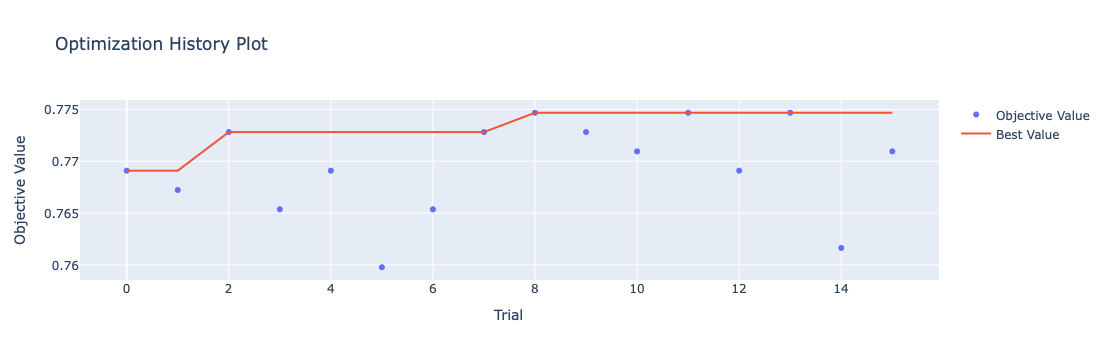

In [19]:
# 1. Optimization History
plot_optimization_history(study).show()

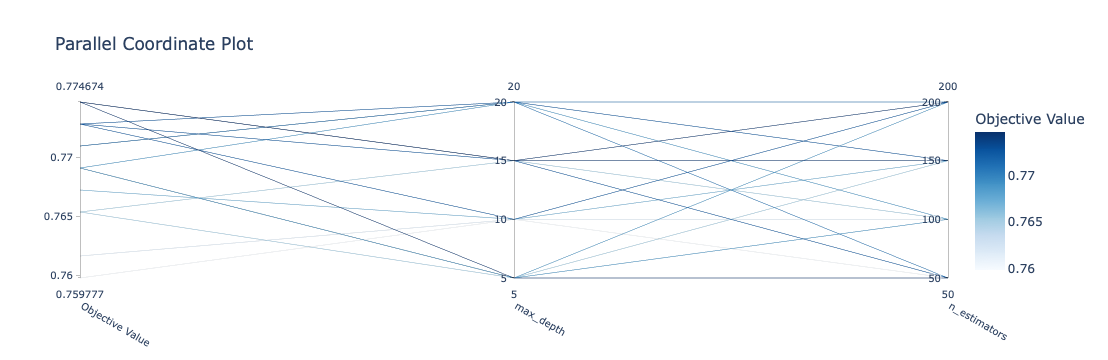

In [20]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

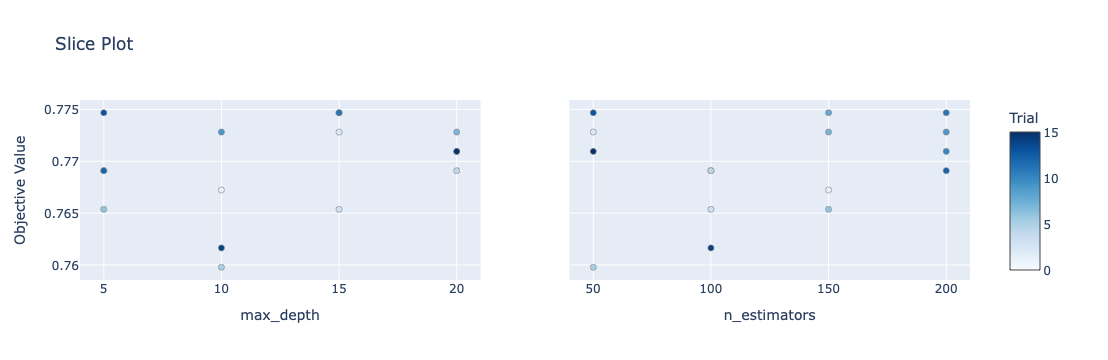

In [21]:
# 3. Slice Plot
plot_slice(study).show()

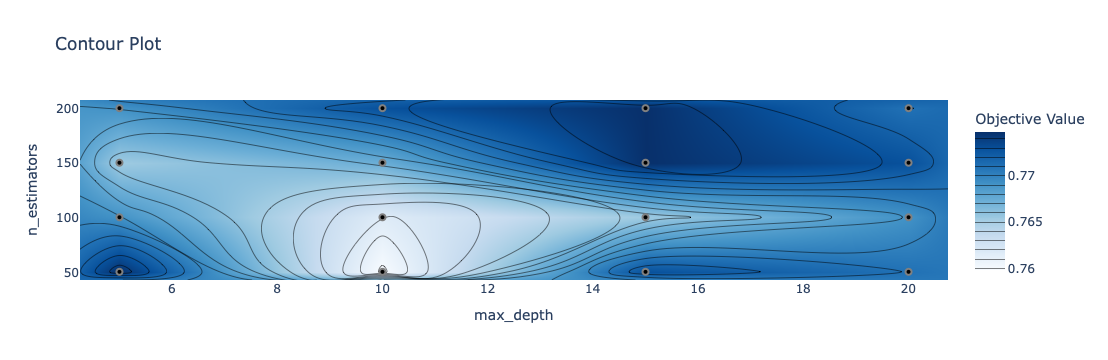

In [22]:
# 4. Contour Plot
plot_contour(study).show()

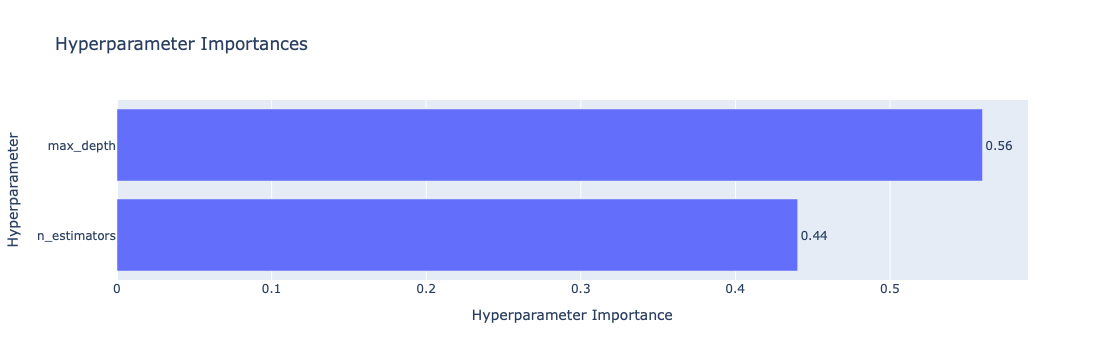

In [23]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

## Optimizing Multiple ML Models

In [24]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [25]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [26]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-03-18 18:34:39,632] A new study created in memory with name: no-name-92e1bf7e-11d9-4ea8-83ec-65263bdf044f
[I 2026-03-18 18:34:40,111] Trial 0 finished with value: 0.7597765363128491 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 267, 'learning_rate': 0.012969155854653679, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.7597765363128491.
[I 2026-03-18 18:34:40,917] Trial 1 finished with value: 0.750465549348231 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 256, 'learning_rate': 0.09158110805110109, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7597765363128491.
[I 2026-03-18 18:34:41,331] Trial 2 finished with value: 0.7653631284916201 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 250, 'learning_rate': 0.019736645349604377, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.7653631

In [27]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'SVM', 'C': 0.1174525887919804, 'kernel': 'linear', 'gamma': 'scale'}
Best trial accuracy: 0.7895716945996275


In [28]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.759777,2026-03-18 18:34:39.635710,2026-03-18 18:34:40.111075,0 days 00:00:00.475365,NaN,NaN,GradientBoosting,NaN,NaN,0.012969,5.0,2.0,10.0,267.0,COMPLETE
1,1,0.750466,2026-03-18 18:34:40.111459,2026-03-18 18:34:40.917777,0 days 00:00:00.806318,NaN,NaN,GradientBoosting,NaN,NaN,0.091581,12.0,4.0,9.0,256.0,COMPLETE
2,2,0.765363,2026-03-18 18:34:40.918090,2026-03-18 18:34:41.331688,0 days 00:00:00.413598,NaN,NaN,GradientBoosting,NaN,NaN,0.019737,5.0,3.0,3.0,250.0,COMPLETE
3,3,0.756052,2026-03-18 18:34:41.331918,2026-03-18 18:34:41.623750,0 days 00:00:00.291832,NaN,NaN,GradientBoosting,NaN,NaN,0.059706,14.0,6.0,9.0,99.0,COMPLETE
4,4,0.785847,2026-03-18 18:34:41.624093,2026-03-18 18:34:41.635555,0 days 00:00:00.011462,0.642733,NaN,SVM,auto,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.789572,2026-03-18 18:34:47.197436,2026-03-18 18:34:47.204767,0 days 00:00:00.007331,0.112718,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
96,96,0.785847,2026-03-18 18:34:47.204982,2026-03-18 18:34:47.219554,0 days 00:00:00.014572,6.705208,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
97,97,0.785847,2026-03-18 18:34:47.219828,2026-03-18 18:34:47.227465,0 days 00:00:00.007637,0.228693,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.776536,2026-03-18 18:34:47.227716,2026-03-18 18:34:47.450487,0 days 00:00:00.222771,NaN,False,RandomForest,NaN,NaN,NaN,7.0,3.0,8.0,233.0,COMPLETE


In [29]:
study.trials_dataframe()['params_classifier'].value_counts()

params_classifier
SVM                 77
GradientBoosting    13
RandomForest        10
Name: count, dtype: int64

In [30]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

params_classifier
GradientBoosting    0.745738
RandomForest        0.768529
SVM                 0.777891
Name: value, dtype: float64

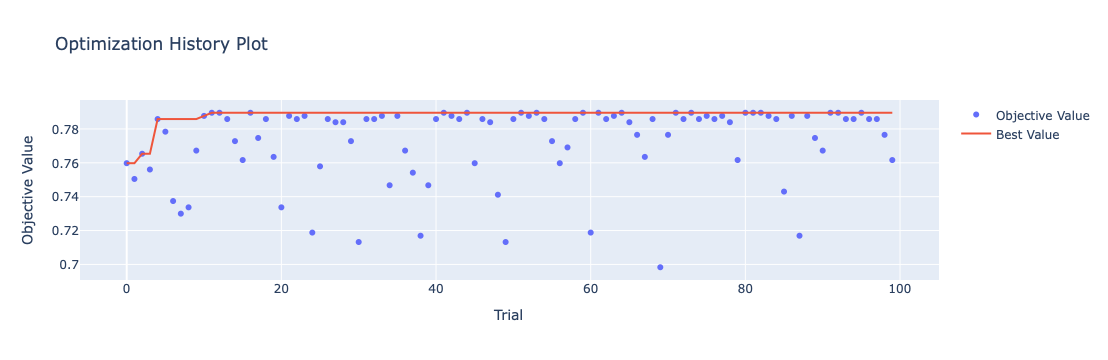

In [31]:
# 1. Optimization History
plot_optimization_history(study).show()

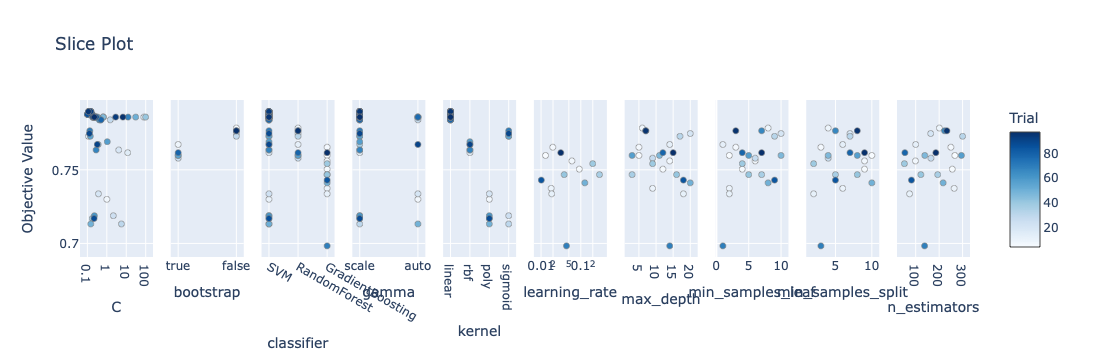

In [32]:
# 3. Slice Plot
plot_slice(study).show()

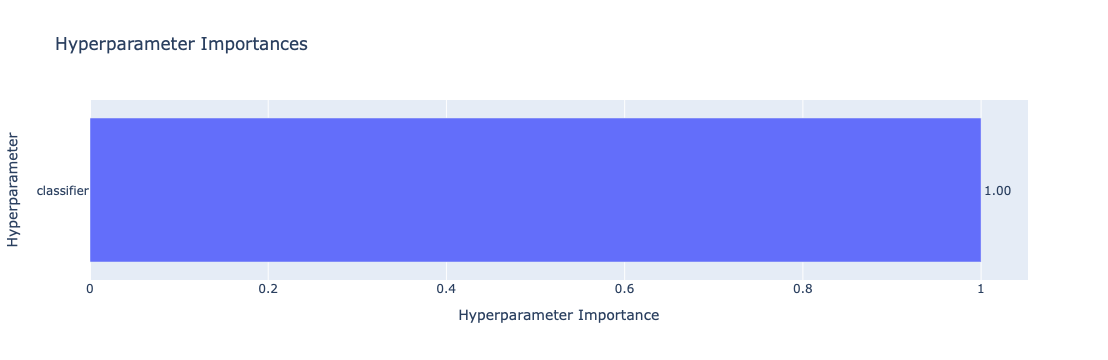

In [33]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

In [35]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Iris dataset
X, y = load_iris(return_X_y=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function for XGBoost
def objective(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=50)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")


[I 2026-03-18 18:35:19,529] A new study created in memory with name: no-name-bdb2f4ee-af1f-4c8d-a562-519e988cde94
[W 2026-03-18 18:35:19,532] Trial 0 failed with parameters: {'lambda': 6.426630247932532e-05, 'alpha': 5.680975548850046e-06, 'eta': 0.10336347479922295, 'gamma': 3.831251856031034e-08, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.7729224371281196, 'colsample_bytree': 0.8685864264448686} because of the following error: ModuleNotFoundError('\nCould not find `optuna-integration` for `xgboost`.\nPlease run `pip install optuna-integration[xgboost]`.').
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/optuna/integration/xgboost.py", line 5, in <module>
    from optuna_integration.xgboost import XGBoostPruningCallback
ModuleNotFoundError: No module named 'optuna_integration'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/opt

ModuleNotFoundError: 
Could not find `optuna-integration` for `xgboost`.
Please run `pip install optuna-integration[xgboost]`.

In [ ]:
! pip install optuna-integration[xgboost]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.9/96.9 kB 3.1 MB/s eta 0:00:00


In [ ]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()